# download

In [2]:
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from jetutils.definitions import DATADIR
from cdsapi import Client

request = {
    "product_type": ["reanalysis"],
    "variable": [
        "u_component_of_wind",
        "v_component_of_wind"
    ],
    "year": "2023",
    "month": [
        "01"
    ],
    "day": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24",
        "25", "26", "27",
        "28", "29", "30",
        "31"
    ],
    "time": [
        "00:00", "06:00", "12:00",
        "18:00"
    ],
    "pressure_level": ["175", "200", "225", "250", "300", "350"],
    "data_format": "netcdf",
    "download_format": "unarchived",
    "area": [90, -180, 0, 180],
    "grid": "0.5/0.5",
}

client = Client()
client.retrieve("reanalysis-era5-pressure-levels", request, "/Users/bandelol/Documents/code_local/data/new_wind/2023.nc")

2025-10-20 10:42:34,397 INFO Request ID is ef52e59b-4907-4004-b47a-136d7bec6a9d
2025-10-20 10:42:34,539 INFO status has been updated to accepted
2025-10-20 10:42:48,373 INFO status has been updated to running
2025-10-20 10:43:07,747 INFO status has been updated to accepted
2025-10-20 10:43:25,390 INFO status has been updated to running
2025-10-20 10:45:28,229 INFO status has been updated to successful


11c09fdf5cb479a136eafe34d81115b7.nc:   0%|          | 0.00/383M [00:00<?, ?B/s]

'/Users/bandelol/Documents/code_local/data/new_wind/2023.nc'

In [ ]:
from ecmwfapi import ECMWFDataServer
from calendar import monthrange
server = ECMWFDataServer()

first_date = (5, 15)
last_date = (6, 29)
def date_string(year: int, month: int, day: int):
    year = str(year).zfill(4)
    month = str(month).zfill(2)
    day = str(day).zfill(2)
    return f"{year}-{month}-{day}"

current_date = first_date
dates = [date_string(2025, *current_date)]
while not current_date == last_date:
    month, day = current_date
    this_month_range = monthrange(2025, month)[1]
    next_day = day + 2
    if next_day > this_month_range:
        next_day = 1
        month = month + 1
    current_date = (month, next_day)
    dates.append(date_string(2025, *current_date))
    
def hdates_from_date(date: str):
    year, month, day = date.split("-")
    years = range(2005, 2025)
    return "/".join([f"{year}-{month}-{day}" for year in years])

for date in dates:
    hdates = hdates_from_date(date)
    server.retrieve({
        "class": "s2",
        "dataset": "s2s",
        "date": date,
        "expver": "prod",
        "hdate": hdates,
        "levtype": "sfc",
        "model": "glob",
        "number": "1/2/3/4/5/6/7/8/9/10",
        "origin": "ecmf",
        "param": "151",
        "step": "0/24/48/72/96/120/144/168/192/216/240/264/288/312/336/360/384/408/432/456/480/504/528/552/576/600/624/648/672/696/720/744/768/792/816/840/864/888/912/936/960/984/1008/1032/1056/1080/1104",
        "stream": "enfh",
        "time": "00:00:00",
        "type": "pf",
        "format": "netcdf",
        "grid": "1.5/1.5",
        "area": "75/-15/30/42.5",
        "target": "output.nc",
    })

2025-08-19 13:21:26 ECMWF API python library 1.6.5
2025-08-19 13:21:26 ECMWF API at https://api.ecmwf.int/v1
2025-08-19 13:21:26 Welcome Hugo Banderier
2025-08-19 13:21:27 In case of problems, please check https://confluence.ecmwf.int/display/WEBAPI/Web+API+FAQ or contact servicedesk@ecmwf.int
2025-08-19 13:21:27 ------------ WARNING ------------
2025-08-19 13:21:27 Access to this dataset is transitioning to a new interface, dates to be announced soon
2025-08-19 13:21:27 For more information on how to access this data in the future, visit https://confluence.ecmwf.int/x/-wUiEw
2025-08-19 13:21:27 ---------------------------------
2025-08-19 13:21:27 Request submitted
2025-08-19 13:21:27 Request id: 68a45e37590535212606ff93
2025-08-19 13:21:27 Request is submitted
2025-08-19 13:21:28 Calling 'nice mars /tmp/20250819-1120/e3/tmp-_mars-KUhArJ-38124d437ed96b54203ca367e0465d06.req'
2025-08-19 13:21:28 Forcing MIR_CACHE_PATH=/data/ec_coeff
2025-08-19 13:21:28 mars - WARN -
2025-08-19 13:21:28

In [15]:
import cdsapi

dataset = "reanalysis-era5-single-levels"
request = {
    "product_type": ["reanalysis"],
    "variable": ["mean_sea_level_pressure"],
    "year": [
        "2005", "2006", "2007",
        "2008", "2009", "2010",
        "2011", "2012", "2013",
        "2014", "2015", "2016",
        "2017", "2018", "2019",
        "2020", "2021", "2022",
        "2023", "2024"
    ],
    "month": [
        "05", "06", "07",
        "08"
    ],
    "day": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24",
        "25", "26", "27",
        "28", "29", "30",
        "31"
    ],
    "time": ["00:00"],
    "format": "netcdf",
    "grid": "1.5/1.5",
    "area": "75/-15/30/42.5",
    "target": "output_rea.nc",
}

client = cdsapi.Client()
client.retrieve(dataset, request).download()

2025-08-19 13:36:51,359 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-19 13:36:51,843 INFO Request ID is c19e6a8d-73c3-4c9f-8559-da3b021e93dc
2025-08-19 13:36:51,903 INFO status has been updated to accepted
2025-08-19 13:37:05,436 INFO status has been updated to running
2025-08-19 13:45:10,913 INFO status has been updated to successful


1e565eb78b81b7b44480ae85ce67c48d.nc:   0%|          | 0.00/5.19M [00:00<?, ?B/s]

'1e565eb78b81b7b44480ae85ce67c48d.nc'

# baby diagnostics

In [45]:
import numpy as np
import xarray as xr
import scoringrules as sr
from jetutils.data import standardize
from jetutils.definitions import get_region
from jetutils.plots import Clusterplot

sr.backends.set_active("numba")
fct = standardize(xr.open_dataarray("output.nc")).transpose("time", "lat", "lon", "number")[:12]
obs = standardize(xr.open_dataarray("1e565eb78b81b7b44480ae85ce67c48d.nc")).sel(time=fct.time)[:12]
res = obs.copy(data=sr.twcrps_ensemble(obs, fct))

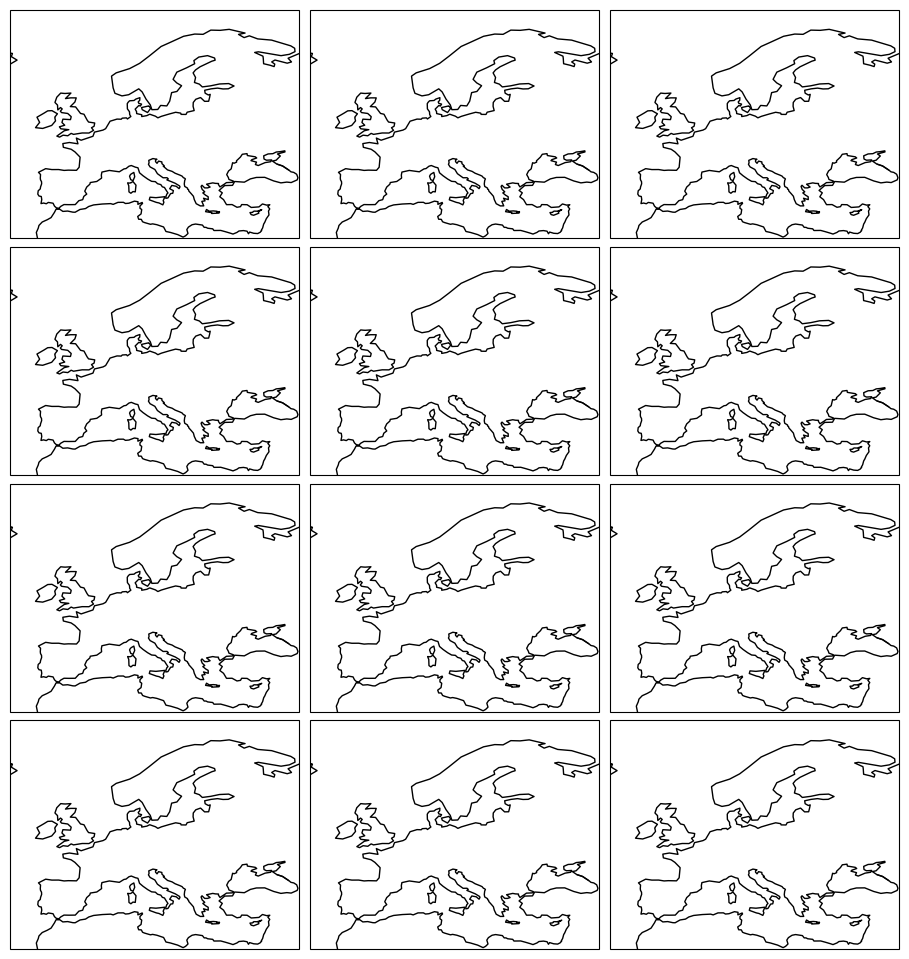

In [43]:
clu = Clusterplot(4, 3, region=get_region(obs))